# **# TSLA.csv 파일에 대한 RNN 수행**
# **202235203 고수호**

In [10]:
import numpy as np, pandas as pd, tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/12week/TSLA.csv')
data = df['Close'].values.reshape(-1, 1)

In [11]:
scaler = MinMaxScaler()
data = scaler.fit_transform(data)

In [12]:
window = 12
X = []
y = []
for i in range(len(data)-window):
  X.append(np.array(data[i:i+window]))
  y.append(data[i+window])
X, y = np.array(X), np.array(y)

In [13]:
TEST_SIZE = 200

X_train = X[:-TEST_SIZE]
X_test = X[-TEST_SIZE:]

y_train = y[:-TEST_SIZE]
y_test = y[-TEST_SIZE:]

In [14]:
model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(64, return_sequences=True, input_shape=(window, 1)),
    tf.keras.layers.SimpleRNN(32),
    tf.keras.layers.Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [15]:
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=50, batch_size=8, verbose=1, validation_data=(X_test, y_test))

Epoch 1/50
343/343 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0018 - val_loss: 0.0086
Epoch 2/50
343/343 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 2.3159e-04 - val_loss: 0.0025
Epoch 3/50
343/343 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 2.9386e-04 - val_loss: 0.0019
Epoch 4/50
343/343 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 1.8455e-04 - val_loss: 0.0016
Epoch 5/50
343/343 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 1.9085e-04 - val_loss: 0.0027
Epoch 6/50
343/343 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 8.1413e-05 - val_loss: 0.0018
Epoch 7/50
343/343 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.3280e-05 - val_loss: 8.6796e-04
Epoch 8/50
343/343 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 1.0328e-04 - val_loss: 8.2577e-04
Epoch 9/50
343/343 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 8.0218e-05 - val_loss: 8.2081e-04
Epoch 10/50
343/343 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 1.4094e-04 - val_loss: 7.8595e-04
Epoch 11/50
343/343 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 6.6137e-05 - val_loss: 8.1

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


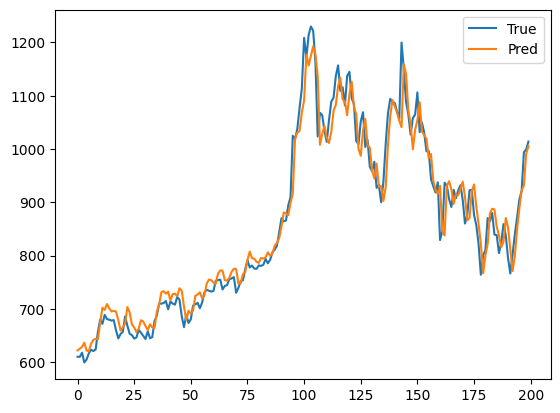

In [16]:
pred = model.predict(X_test)
plt.plot(scaler.inverse_transform(y_test), label='True')
plt.plot(scaler.inverse_transform(pred), label='Pred')
plt.legend()
plt.show()